# ZINC Feasibility-Rate Hyperparameter Search

This notebook trains a ZINC graph generator on a size-filtered subset, scores each fitted model by feasible generation rate, and runs a small random search over an explicitly typed hyperparameter space.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import numpy as np
import pandas as pd
from IPython.display import display

for _root in [Path.cwd(), Path.cwd().parent]:
    if (_root / 'conditional_node_field_graph_generator').exists():
        REPO_ROOT = _root.resolve()
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise ModuleNotFoundError("Could not locate 'conditional_node_field_graph_generator'.")

from conditional_node_field_graph_generator.extensions.demo import (
    build_graph_generator,
    build_zinc_dataset,
    sample_hyperparameter_configuration,
)
from conditional_node_field_graph_generator.extensions.molecular import draw_molecules


/home/fabrizio/miniconda3/envs/py312/lib/python3.12/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## Dataset

Specify only the size range and number of molecules to keep the ZINC setup compact.

Corpus cache: /mnt/data/sync/Projects/GraphGen/notebooks/datasets/zinc
Available node counts: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ... [29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
Loaded graphs: 290
Distinct node labels: 9 | ['Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S']
Distinct edge labels: 4 | ['1', '2', '3', 'AROMATIC']


,zinc_id,smiles,node_count,edge_count,logP,qed,SAS
0,None,C=C(Br)CON,6,5,0.7853,0.602918,3.834174
1,None,Br[C@H]1CC[NH2+]C1,6,6,-0.2830,0.474086,6.467389
2,None,C/C(I)=C/CI,6,5,2.7602,0.513224,4.340924
3,None,Cl/C=C/C(Cl)(Cl)Cl,7,6,3.1091,0.495470,4.165780
4,None,O[C@@H](CBr)C1CC1,7,7,1.1522,0.615928,3.383327


[09:59:37] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 6
[09:59:37] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7


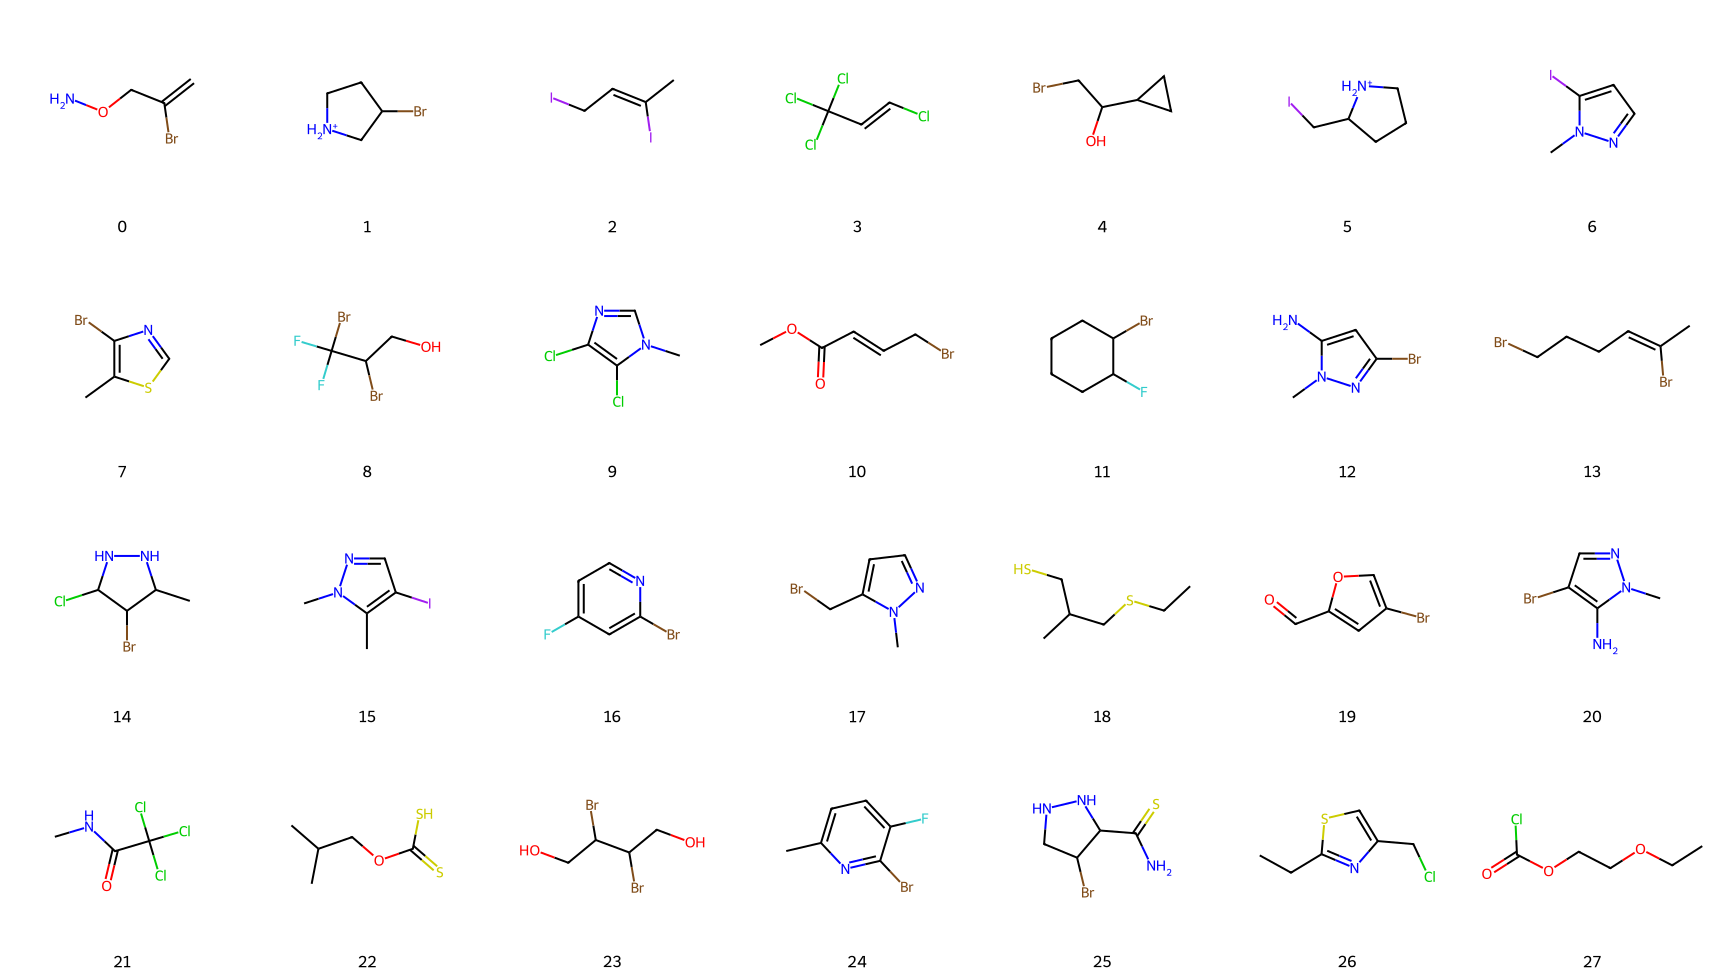

In [4]:
NOTEBOOK_DATA_ROOT = REPO_ROOT / 'notebooks' / 'datasets'
ARTIFACT_ROOT = REPO_ROOT / '.artifacts' / 'zinc_hyperparameter_search'
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'

NUM_EXAMPLES = 500
MIN_SIZE = 4
MAX_SIZE = 10

graphs, zinc_metadata, corpus_manifest = build_zinc_dataset(
    dataset_dir=ZINC_DATA_ROOT,
    num_examples=NUM_EXAMPLES,
    min_size=MIN_SIZE,
    max_size=MAX_SIZE,
)

node_label_set = sorted({attrs.get('label') for graph in graphs for _, attrs in graph.nodes(data=True) if attrs.get('label') is not None}, key=str)
edge_label_set = sorted({attrs.get('label') for graph in graphs for _, _, attrs in graph.edges(data=True) if attrs.get('label') is not None}, key=str)

print(f"Corpus cache: {ZINC_DATA_ROOT}")
print(f"Available node counts: {corpus_manifest['node_counts'][:10]} ... {corpus_manifest['node_counts'][-10:]}")
print(f"Loaded graphs: {len(graphs)}")
print(f"Distinct node labels: {len(node_label_set)} | {node_label_set}")
print(f"Distinct edge labels: {len(edge_label_set)} | {edge_label_set}")
display(zinc_metadata.head())
draw_molecules(graphs[:7*4])


## Search Space

The search space is explicit: every tunable parameter has a range and a declared type. The feasible-rate score configuration is fixed for the whole experiment and is not part of the search space.

In [5]:
N_TRIALS = 20
SCORE_N_SAMPLES = 16
SCORE_MAX_FEASIBILITY_ATTEMPTS = 10
SCORE_FEASIBILITY_CANDIDATES_PER_ATTEMPT = 32
SEARCH_RANDOM_STATE = 42
VERBOSE = 1

base_generator_kwargs = {
    'nbits': 11,
    'verbose': VERBOSE,
    'latent_embedding_dimension': 128,
    'number_of_transformer_layers': 3,
    'transformer_attention_head_count': 4,
    'transformer_dropout': 0.15,
    'learning_rate': 2e-4,
    'maximum_epochs': 80,
    'batch_size': 16,
    'total_steps': 80,
    'verbose_epoch_interval': 10,
    'enable_early_stopping': True,
    'early_stopping_monitor': 'val_total',
    'early_stopping_mode': 'min',
    'early_stopping_patience': 15,
    'early_stopping_min_delta': 5.0,
    'restore_best_checkpoint': True,
    'use_feasibility_filtering': True,
    'feasibility_failure_mode': 'return_partial',
    'decoder_enforce_connectivity': True,
    'decoder_n_jobs': 1,
}

search_space = {
    'lambda_degree_importance': {'type': 'real', 'low': 0.1, 'high': 4.0},
    'lambda_node_exist_importance': {'type': 'real', 'low': 0.1, 'high': 4.0},
    'lambda_node_count_importance': {'type': 'real', 'low': 0.0, 'high': 2.0},
    'lambda_node_label_importance': {'type': 'real', 'low': 0.1, 'high': 4.0},
    'lambda_edge_label_importance': {'type': 'real', 'low': 0.1, 'high': 4.0},
    'lambda_direct_edge_importance': {'type': 'real', 'low': 0.1, 'high': 4.0},
    'lambda_edge_count_importance': {'type': 'real', 'low': 0.0, 'high': 2.0},
    'lambda_degree_edge_consistency_importance': {'type': 'real', 'low': 0.0, 'high': 2.0},
    'lambda_auxiliary_edge_importance': {'type': 'real', 'low': 0.0, 'high': 2.0},
    'sampling_steps': {'type': 'int', 'low': 20, 'high': 120},
    'sampling_step_size': {'type': 'real', 'low': 0.01, 'high': 0.10},
    'degree_temperature': {'type': 'real', 'low': 0.7, 'high': 1.5},
}

display(pd.DataFrame(search_space).T)


,type,low,high
lambda_degree_importance,real,0.1,4.0
lambda_node_exist_importance,real,0.1,4.0
lambda_node_count_importance,real,0.0,2.0
lambda_node_label_importance,real,0.1,4.0
lambda_edge_label_importance,real,0.1,4.0
lambda_direct_edge_importance,real,0.1,4.0
lambda_edge_count_importance,real,0.0,2.0
lambda_degree_edge_consistency_importance,real,0.0,2.0
lambda_auxiliary_edge_importance,real,0.0,2.0
sampling_steps,int,20,120


## Trial Runner

The score is the candidate-level feasible rate returned by `graph_generator.score_feasible_rate(...)`. `max_feasibility_attempts`, `feasibility_candidates_per_attempt`, and `n_samples` are fixed experiment settings here, so the search only explores generator hyperparameters.

In [6]:
def run_trial(trial_id, sampled_params):
    trial_root = ARTIFACT_ROOT / f'trial_{trial_id:03d}'
    trial_root.mkdir(parents=True, exist_ok=True)

    graph_generator = build_graph_generator(
        **base_generator_kwargs,
        **sampled_params,
        artifact_root=trial_root / 'artifacts',
        checkpoint_root=trial_root / 'checkpoints',
    )
    graph_generator.fit(graphs)

    score_info = graph_generator.score_feasible_rate(
        n_samples=SCORE_N_SAMPLES,
        max_feasibility_attempts=SCORE_MAX_FEASIBILITY_ATTEMPTS,
        feasibility_candidates_per_attempt=SCORE_FEASIBILITY_CANDIDATES_PER_ATTEMPT,
    )
    return {
        'trial_id': trial_id,
        **sampled_params,
        **score_info,
    }


## Random Search

In [ ]:
results = []
for trial_id in range(1, N_TRIALS + 1):
    sampled_params = sample_hyperparameter_configuration(
        search_space,
        random_state=SEARCH_RANDOM_STATE + trial_id,
    )
    print(f"\n=== Trial {trial_id}/{N_TRIALS} ===")
    print(sampled_params)
    trial_result = run_trial(trial_id, sampled_params)
    results.append(trial_result)
    print(
        f"score={trial_result['score']:.3f} | "
        f"fulfilled_rate={trial_result['fulfilled_rate']:.3f} | "
        f"accepted_slots={trial_result['accepted_slots']}/{trial_result['n_samples']}"
    )

results_df = pd.DataFrame(results).sort_values(['score', 'fulfilled_rate'], ascending=False).reset_index(drop=True)
display(results_df)



=== Trial 1/20 ===
{'lambda_degree_importance': 2.6439671245335514, 'lambda_node_exist_importance': 0.27072376219208677, 'lambda_node_count_importance': 0.04005917374843371, 'lambda_node_label_importance': 3.3729290717930174, 'lambda_edge_label_importance': 2.389857885593428, 'lambda_direct_edge_importance': 0.9763503977941352, 'lambda_edge_count_importance': 1.503584543637231, 'lambda_degree_edge_consistency_importance': 0.5273843949567494, 'lambda_auxiliary_edge_importance': 0.839955819432536, 'sampling_steps': 84, 'sampling_step_size': 0.0959783121299114, 'degree_temperature': 1.4135213353464342}
Fitting model on 290 graphs
Fitting feasibility estimator on 290 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary loca

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


In [ ]:
best_row = results_df.iloc[0]
print('Best configuration:')
display(best_row.to_frame(name='value'))
